<a href="https://colab.research.google.com/github/swirita/Cirrhosis-Prediction/blob/main/Cirrhosis_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cirrhosis Prediction
- Author: Siwar Ehwass

## Project Overview

### Data Dictionary

| Feature | Description |
|---------|-------------|
| **ID** | Unique identifier for each patient. |
| **N_Days** | Number of days between registration and the earlier of death, liver transplantation, or the end of the study (July 1986). |
| **Status** | Patient outcome: **C** = censored, **CL** = censored due to liver transplant, **D** = death. |
| **Drug** | Treatment received: **D-penicillamine** or **Placebo**. |
| **Age** | Patient age in **days**. |
| **Sex** | Patient gender: **M** = Male, **F** = Female. |
| **Ascites** | Presence of ascites: **Y** = Yes, **N** = No. |
| **Hepatomegaly** | Presence of enlarged liver: **Y** = Yes, **N** = No. |
| **Spiders** | Presence of spider angiomas: **Y** = Yes, **N** = No. |
| **Edema** | Edema status: **N** = No edema, **S** = Edema controlled with diuretics, **Y** = Edema despite diuretic therapy. |
| **Bilirubin** | Serum bilirubin level (mg/dL). |
| **Cholesterol** | Serum cholesterol level (mg/dL). |
| **Albumin** | Serum albumin level (g/dL). |
| **Copper** | Urine copper level (µg/day). |
| **Alk_Phos** | Alkaline phosphatase level (U/L). |
| **SGOT** | Serum glutamic-oxaloacetic transaminase (SGOT) level (U/mL). |
| **Triglycerides** | Serum triglyceride level (mg/dL). |
| **Platelets** | Platelet count (thousands per mL). |
| **Prothrombin** | Prothrombin time (seconds). |
| **Stage** | Histologic stage of liver disease (**1**, **2**, **3**, or **4**) *(Target Variable)*. |

###  Dataset Overview

> ### Target
>
> The target variable is **`Stage`**, which represents the stage of liver cirrhosis (Stages 1–4). This makes the dataset suitable for a **multiclass classification** task.
>
> Each row represents **one patient** and their medical information.
>
> ### Features
>
> The dataset contains **20 columns** in total. Excluding the target (`Stage`), there are **19 features**. The `ID` column can also be removed since it is only an identifier and does not contribute to prediction.
>
> ### Number of Rows
>
> The dataset contains **424 rows**.
>
> ### Opportunities for Feature Selection
>
> - Remove the `ID` column because it has no predictive value.
> - Use feature selection techniques such as **Random Forest Feature Importance**, **Forward Selection**, or **Premutation Importance** to identify the most important features.
> - Apply **Principal Component Analysis (PCA)** to reduce dimensionality while retaining most of the dataset's information.
>
> ### Expected Challenges
>
> - Missing values in several features require imputation.
> - The dataset is relatively small, increasing the possibility of overfitting.
> - The target classes are imbalanced, which may affect prediction performance for some stages.
> - The dataset contains both categorical and numerical features that require different preprocessing techniques.

## Imports

In [65]:
# Download Data from Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/cirrhosis-prediction-dataset")

print("Path to dataset files:", path)

import os
print(os.listdir("/kaggle/input/cirrhosis-prediction-dataset"))

Using Colab cache for faster access to the 'cirrhosis-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/cirrhosis-prediction-dataset
['cirrhosis.csv']


In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn import set_config
set_config(transform_output='pandas')

## Load and Inspect Data

In [38]:
# create dataframe
df = pd.read_csv("/kaggle/input/cirrhosis-prediction-dataset/cirrhosis.csv")
# check information about df
df.info()
# check first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


> What we can interpret from this:
>  1) We have 418 rows, and 20 columns. A small dataset.
>  2) `ID` us just an identifier, it does not help with model training.
>  3) There is null values in `Drug` & `Copper` and multipile other features.
>  4) `Edema` is an Ordinal Feature.

## Clean Data

### Dropping ID

In [39]:
df= df.drop(columns=['ID'])

### Duplicated Rows

In [40]:
# check for duplicated data
df.duplicated().sum()

np.int64(0)

- there are no duplicated values



### Unique Identifiers

In [41]:
# check for unique percentage
df.nunique() / len(df) * 100

,0
N_Days,95.454545
Status,0.717703
Drug,0.478469
Age,82.296651
Sex,0.478469
Ascites,0.478469
Hepatomegaly,0.478469
Spiders,0.478469
Edema,0.717703
Bilirubin,23.444976


> **Notes:**
> - `N_Days` and `Age` have a high percentage of unique values, which is expected since they are continuous variables. They provide useful information and should be retained.
>
> - Most categorical features (`Drug`, `Sex`, `Ascites`, `Hepatomegaly`, and `Spiders`) have very low uniqueness because they contain only a few categories, which is normal for categorical data.
>
> - `Status`, `Edema`, and `Stage` also have low unique percentages because they contain only a small number of predefined classes.
>
> - Laboratory measurements such as `Bilirubin`, `Cholesterol`, `Albumin`, `Copper`, `Alk_Phos`, `SGOT`, `Triglycerides`, `Platelets`, and `Prothrombin` show moderate to high uniqueness, indicating they are continuous features with a good range of values.
>
> - Overall, there are **no high-cardinality categorical features**, so categorical encoding should be straightforward. The continuous features also show sufficient variation, making them useful for model training.

### Data Inconsistencies
- There is no data inconsistencies

In [42]:
# filter out both num and object features
num_cols=df.select_dtypes('number').columns # select numbers
cat_cols=df.select_dtypes('object').columns # select objects

# loop through each one's value counts (objects)
for col in cat_cols:
    print(f'Value counts of {col}:\n {df[col].value_counts(dropna=False)} \n')

Value counts of Status:
 Status
C     232
D     161
CL     25
Name: count, dtype: int64 

Value counts of Drug:
 Drug
D-penicillamine    158
Placebo            154
NaN                106
Name: count, dtype: int64 

Value counts of Sex:
 Sex
F    374
M     44
Name: count, dtype: int64 

Value counts of Ascites:
 Ascites
N      288
NaN    106
Y       24
Name: count, dtype: int64 

Value counts of Hepatomegaly:
 Hepatomegaly
Y      160
N      152
NaN    106
Name: count, dtype: int64 

Value counts of Spiders:
 Spiders
N      222
NaN    106
Y       90
Name: count, dtype: int64 

Value counts of Edema:
 Edema
N    354
S     44
Y     20
Name: count, dtype: int64 



> What we can get from this:
> 1) For `Drug` feature:
>     - Missing features -> impute with most frequent or new constant 'MISSING'
>     - It has 106 null values.
> 2) For `Hepatomegaly` Feature:
>     - It has 106 null values.
> 3) For `Spiders` Feature:
>     - It has 106 null values.
>     - Missing features -> impute with most frequent or new constant 'MISSING'
> 4) For `Edema` Feature:
>     - It is an Ordinal Feature ( N < S < Y).


In [43]:
# check describe for numbers (loop)
for col in num_cols:
    print(f'Describe for {col}\n {df[col].describe()}')

Describe for N_Days
 count     418.000000
mean     1917.782297
std      1104.672992
min        41.000000
25%      1092.750000
50%      1730.000000
75%      2613.500000
max      4795.000000
Name: N_Days, dtype: float64
Describe for Age
 count      418.000000
mean     18533.351675
std       3815.845055
min       9598.000000
25%      15644.500000
50%      18628.000000
75%      21272.500000
max      28650.000000
Name: Age, dtype: float64
Describe for Bilirubin
 count    418.000000
mean       3.220813
std        4.407506
min        0.300000
25%        0.800000
50%        1.400000
75%        3.400000
max       28.000000
Name: Bilirubin, dtype: float64
Describe for Cholesterol
 count     284.000000
mean      369.510563
std       231.944545
min       120.000000
25%       249.500000
50%       309.500000
75%       400.000000
max      1775.000000
Name: Cholesterol, dtype: float64
Describe for Albumin
 count    418.000000
mean       3.497440
std        0.424972
min        1.960000
25%        3.242

> **Notes:**
> - Most numerical features have a wide range of values, which is expected for medical measurements. Features such as `Age`, `N_Days`, `Bilirubin`, `Copper`, `Alk_Phos`, `SGOT`, and `Platelets` show good variability and are likely to provide useful information for the model.
>
> - Several features (`Cholesterol`, `Copper`, `Alk_Phos`, and `Tryglicerides`) appear to have outliers. Since these are clinical measurements, the extreme values may represent patients with severe liver disease rather than errors. Therefore, they will be examined using visualizations and retained unless they are found to be invalid.
>
> - `Cholesterol`, `Copper`, `Alk_Phos`, and `Tryglicerides` also contain a considerable number of missing values, so an appropriate imputation strategy will be required during preprocessing.
>
> - `Stage` is the target variable with four possible classes (1–4), confirming that this is a multiclass classification problem.

### Missing Values

> We are going to impute missing values in this step with a null value using `np.nan`, so later in model preprocessing we can impute without causing data leakage.
>
> The Features with null values are:
> - `Drug`, `Spiders`, `Ascites`, `Hepatomegaly`: 106 null values, (impute with constant 'MISSING' to not introduce bias, missing values could be important medical measurements)
> - `SGOT`, `Alk_Phos`: 106 null values, impute with mean or median.
> - `Copper`: 108 null values impute with median or mean
> - `Cholesterol`: 134, impute with median or mean
> - `Tryglicerides`: 136, impute with median or mean
> - `Platelets`: 11, median or mean
> - `Prothrombin`: 11, median or mean
> - `Stage`: Drop missing values (Target)


---


> **Target Variable (`Stage`):**
>
> - The target feature `Stage` contains **6 missing values**.
> - Since `Stage` is the value we want the model to predict, we should **not impute** these missing values.
> - Instead, the **6 rows with missing target values will be removed** because a machine learning model cannot be trained without the correct target label.


In [44]:
# see columns and rows where NaN is present in df
df.isna().sum()

,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0
Bilirubin,0


In [45]:
# drop missing values from target
df = df.dropna(subset=['Stage']).copy()

#### Inspecting Categorical Features

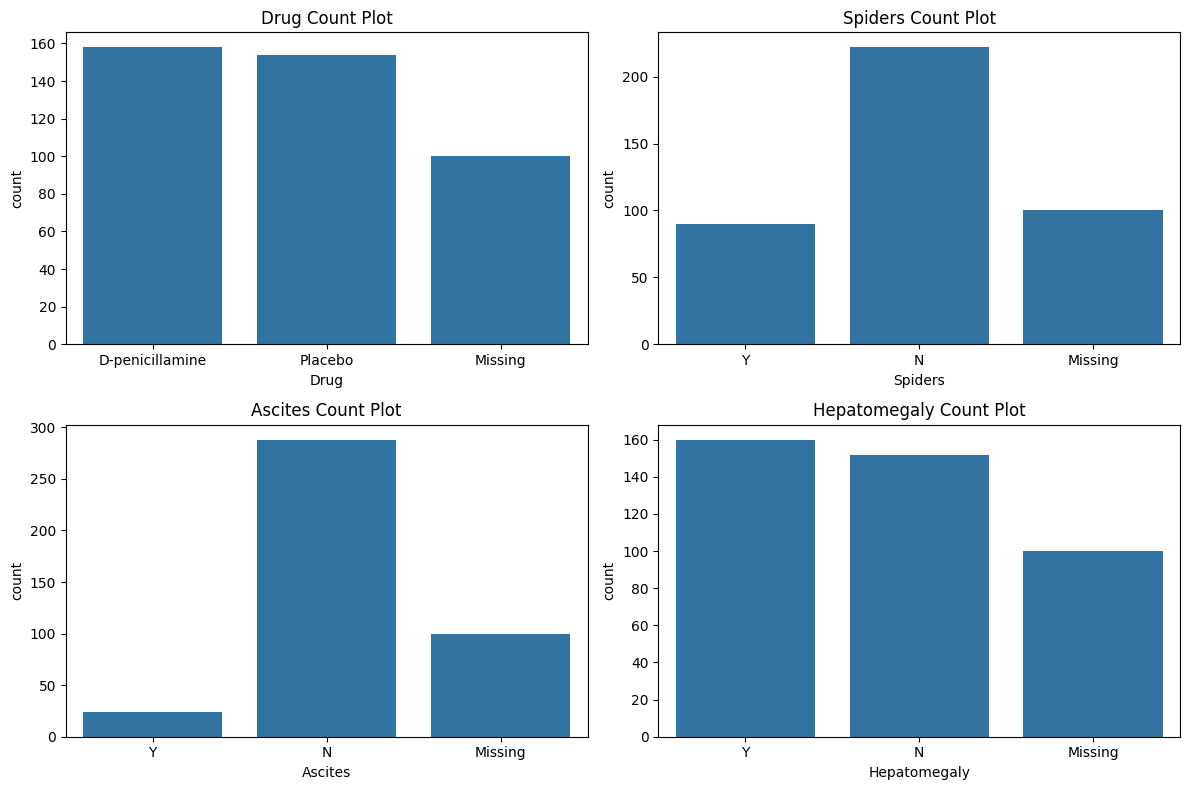

In [46]:
cat_cols = ['Drug', 'Spiders', 'Ascites', 'Hepatomegaly']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    # Temporary copy for visualization only
    temp = df[col].fillna("Missing")

    sns.countplot(x=temp, ax=axes[i])
    axes[i].set_title(f"{col} Count Plot")
    axes[i].set_xlabel(col)

plt.tight_layout()

> **Observations:**
>
> - The features `Drug`, `Spiders`, `Ascites`, and `Hepatomegaly` have missing values.
> - Each feature has about **106 missing values**, so dropping these rows would remove a large amount of data.
> - We will **not** fill the missing values with the mode because it would increase the most common category and may introduce bias.
> - Instead, we will replace the missing values with a new category called **"MISSING"**.
> - This keeps all the data and lets the model know that the value was originally missing, which may be useful for making predictions.

#### Inspecting Numeric Columns

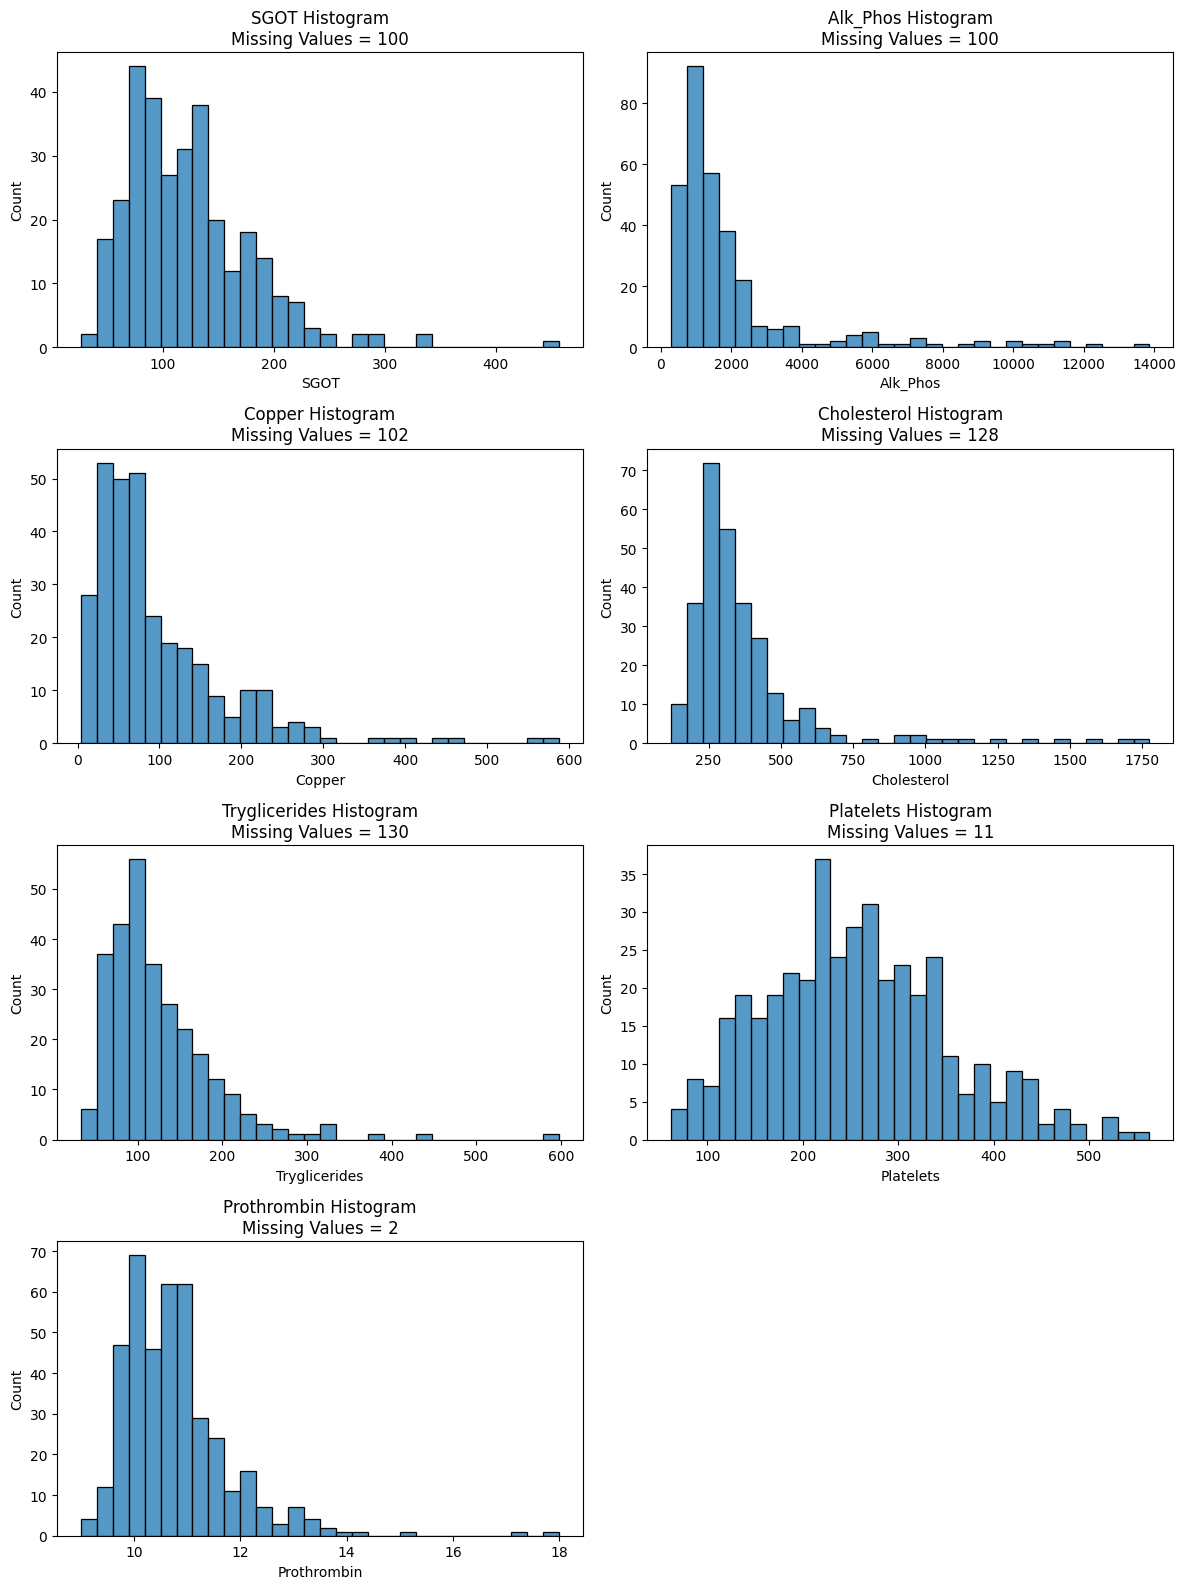

In [47]:
num_cols = [
    'SGOT',
    'Alk_Phos',
    'Copper',
    'Cholesterol',
    'Tryglicerides',
    'Platelets',
    'Prothrombin'
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    missing = df[col].isna().sum()

    sns.histplot(data=df, x=col, bins=30, ax=axes[i])

    axes[i].set_title(f"{col} Histogram\nMissing Values = {missing}")

# Remove the extra empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()

> **Observations:**
>
> - The numerical features (`SGOT`, `Alk_Phos`, `Copper`, `Cholesterol`, `Tryglicerides`, `Platelets`, and `Prothrombin`) contain missing values.
> - Most of these features are **right-skewed** and contain some **outliers**.
> - Because the data is not normally distributed, the **median** is a better choice than the mean for filling the missing values.
> - The median is less affected by extreme values, so it keeps the data more representative.
> - Therefore, all missing values in these numerical features will be imputed using the **median**.

## Exploratory Data Analysis

### Correlation Heatmap


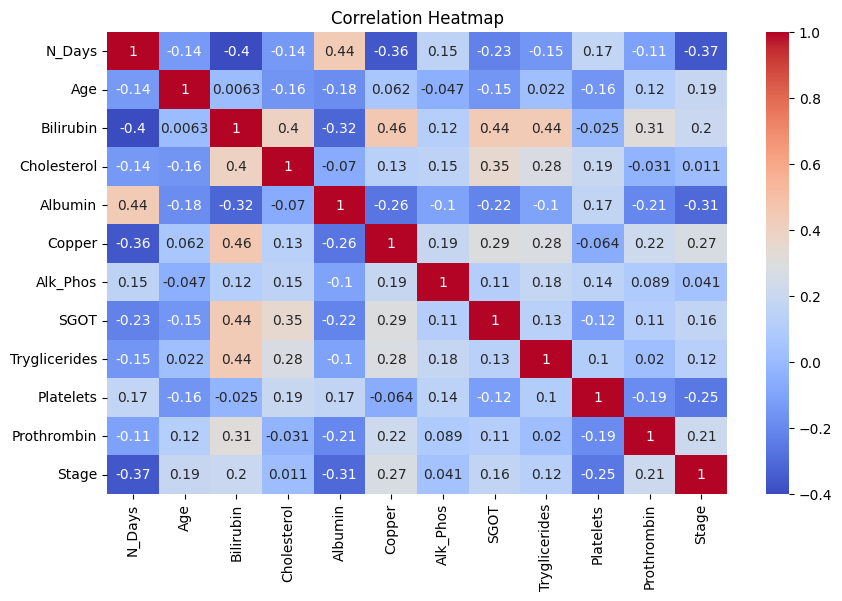

In [50]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
ax = sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title("Correlation Heatmap");

> **Observations:**
>
> - The correlation heatmap shows that most numerical features have weak to moderate correlations with each other.
> - `Cholesterol` (0.01) and `Alk_Phos` (0.04) have very weak linear correlations with the target (`Stage`).
> - These features will not be removed based only on the correlation heatmap because they may still provide useful information to machine learning models.
> - No pair of numerical features has a correlation greater than **0.80**, indicating that there is **no severe multicollinearity**.
> - Therefore, no numerical features will be removed due to multicollinearity.

## Feature Inspection

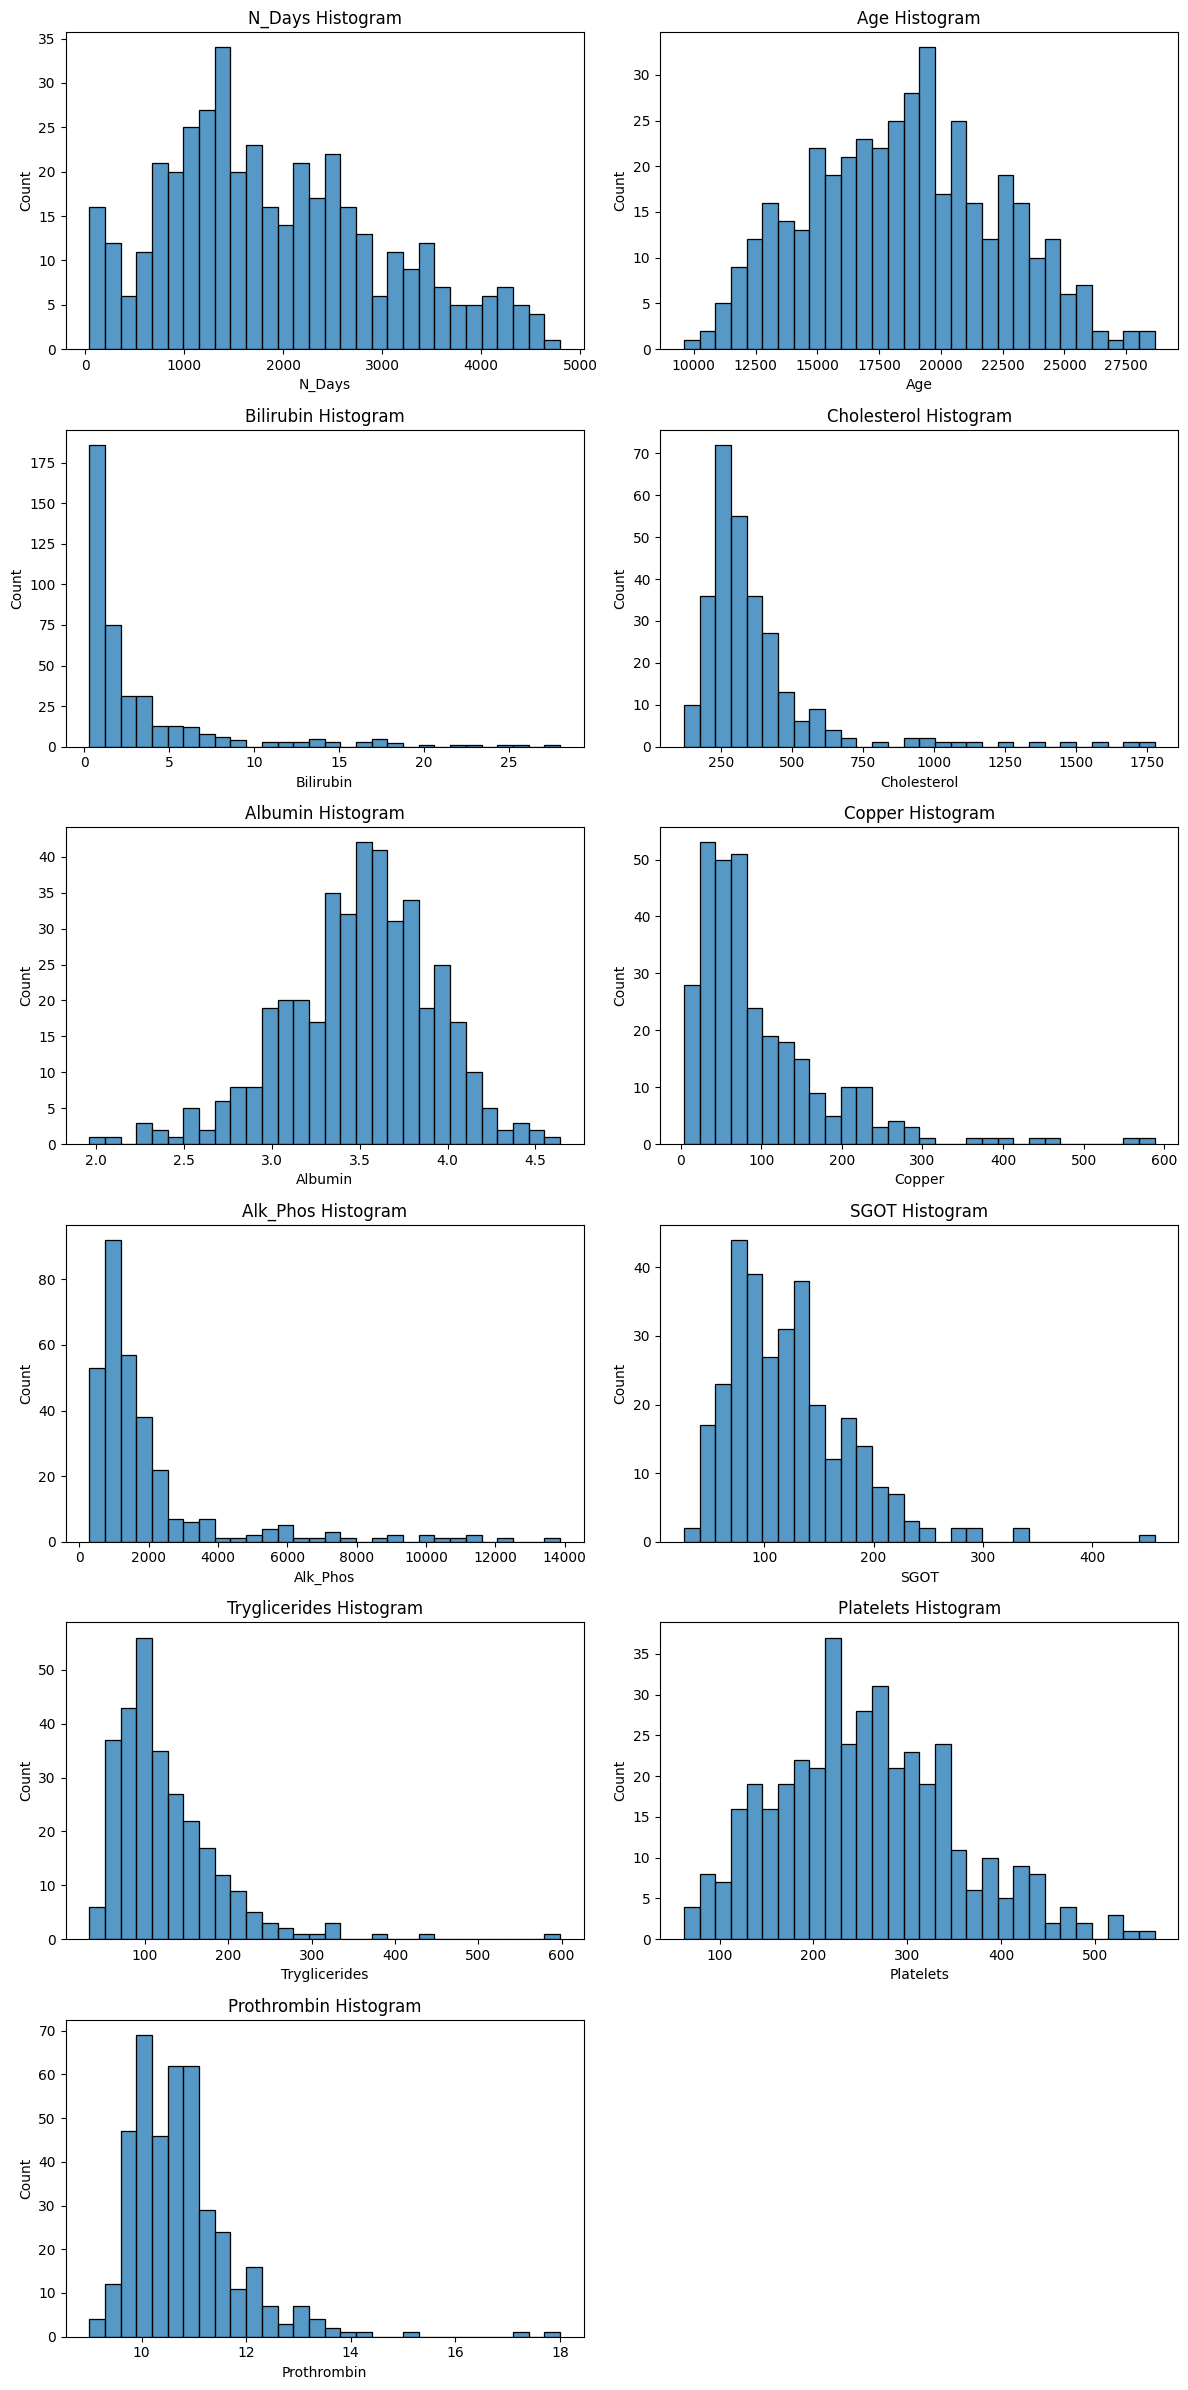

In [ ]:
num_cols=df.select_dtypes('number').drop(columns=['Stage']).columns
fig, axes = plt.subplots(6, 2, figsize=(12, 24))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, bins=30, ax=axes[i])

    axes[i].set_title(f"{col} Histogram")

# Remove the extra empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()

> **Observations:**
>
> - `Age`, `Albumin`, and `N_Days` have distributions that are closer to normal.
> - `Bilirubin`, `Cholesterol`, `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, `Platelets`, and `Prothrombin` are mostly right-skewed.
> - Some numerical features contain very high values, which may be outliers.
> - These high values may represent real medical cases, so they should not be removed without investigation.
> - Missing numerical values will be filled using the **median**.
> - The median is a good choice because it is less affected by extreme values and skewed distributions.
> - The imputer will be fitted only on the training data using a pipeline to avoid data leakage.

### Inspect Outliers

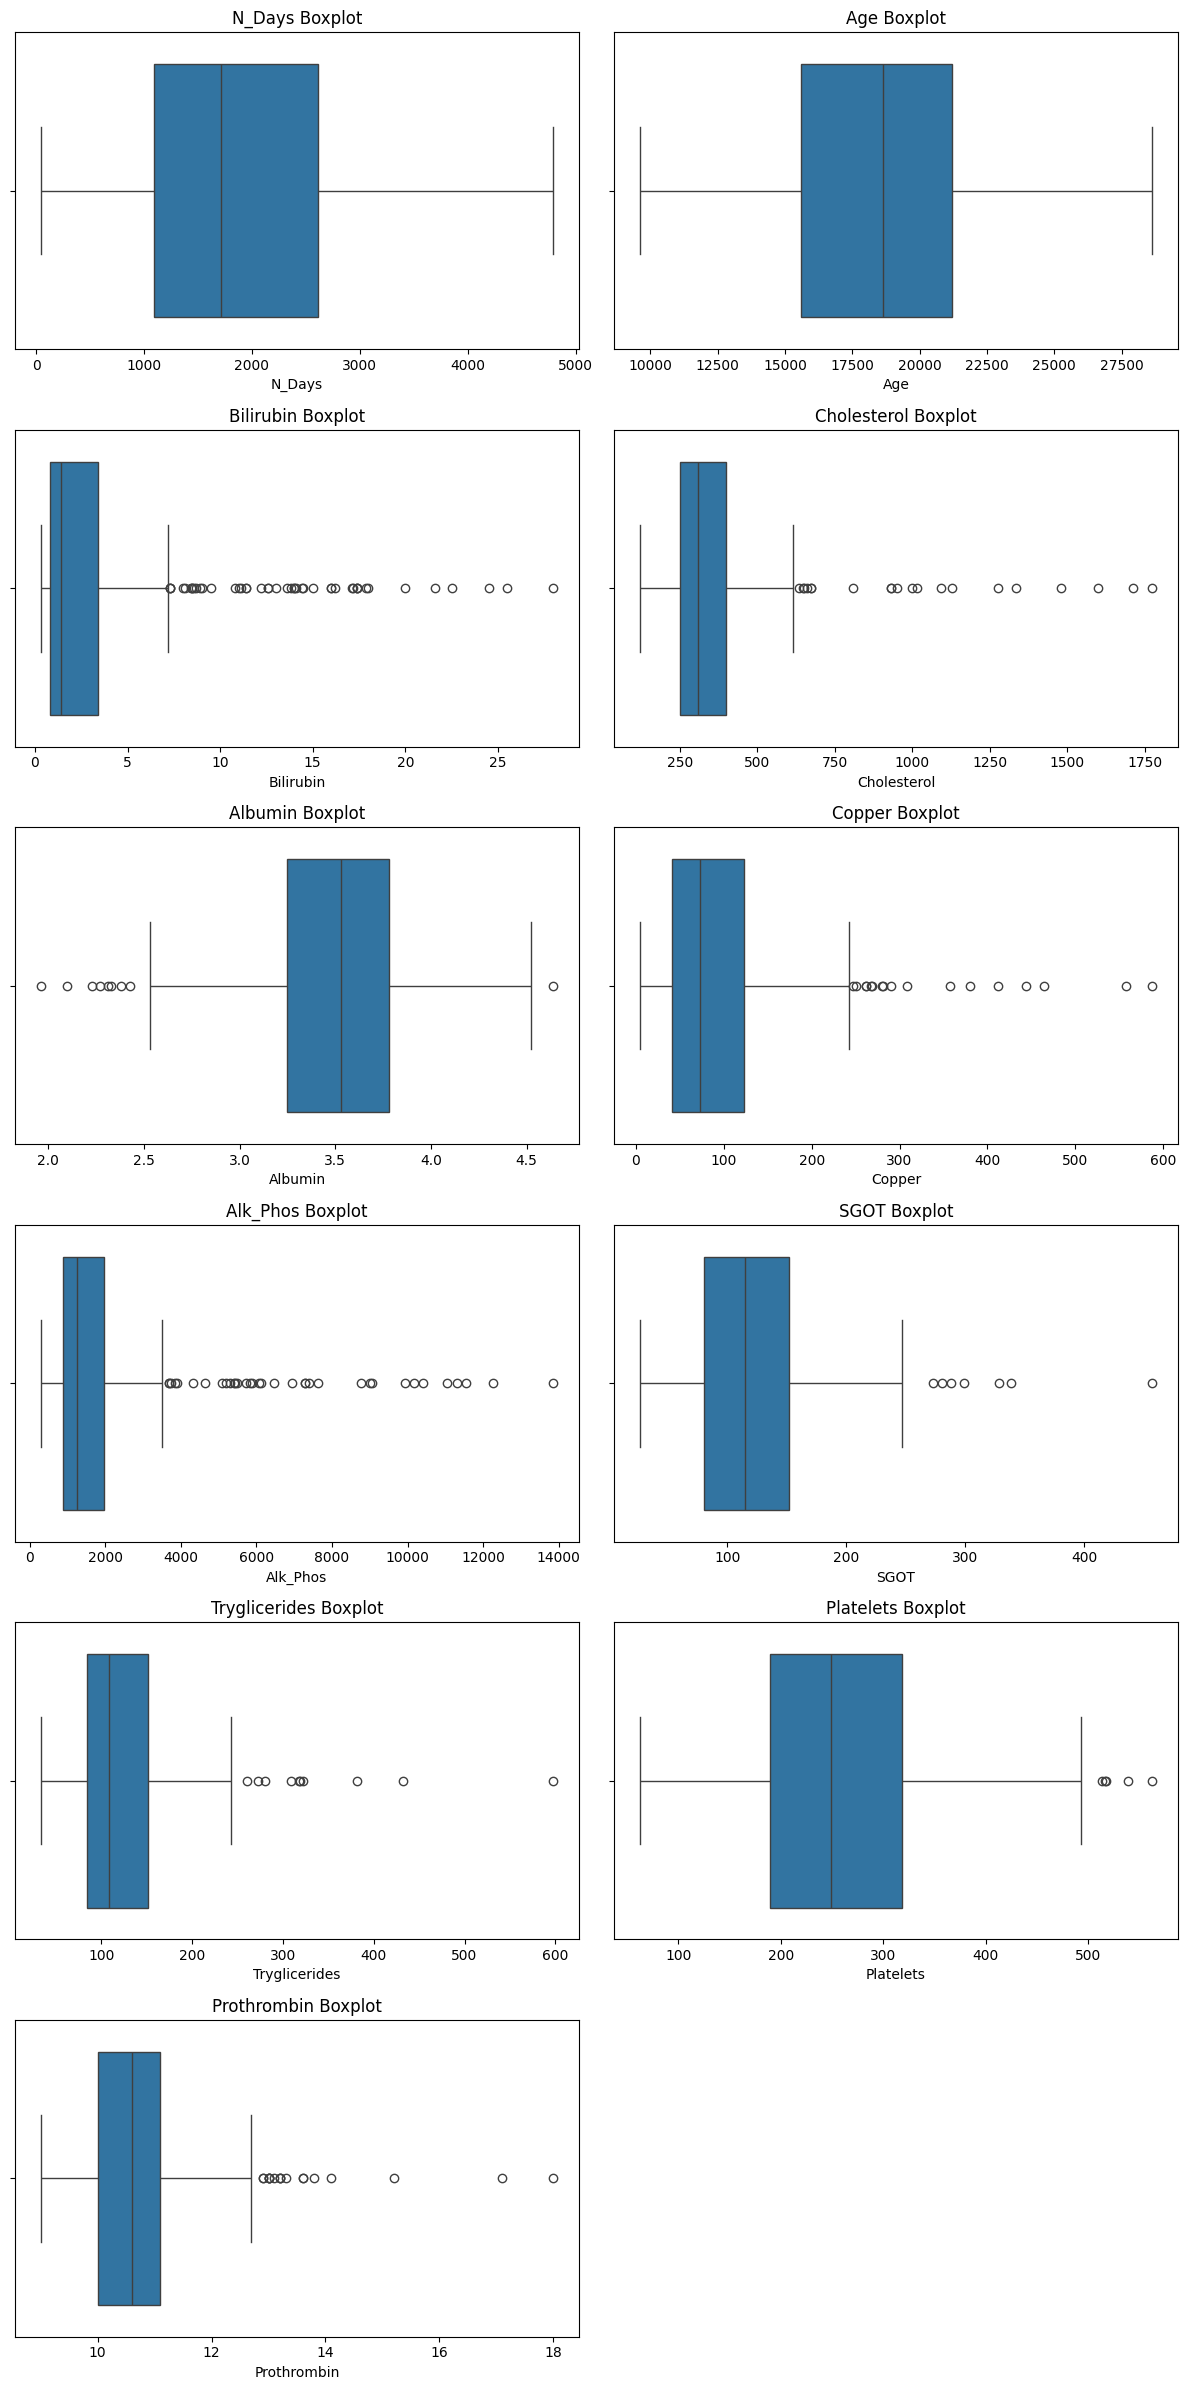

In [ ]:
num_cols=df.select_dtypes('number').drop(columns=['Stage']).columns
# boxplot
fig, axes = plt.subplots(6, 2, figsize=(12, 24))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"{col} Boxplot")

# Remove unused plots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

> **Observations:**
>
> - Boxplots were used to check for possible outliers in the numerical features.
> - `N_Days` and `Age` do not show noticeable outliers.
> - `Albumin` contains a few low outliers.
> - `Bilirubin`, `Cholesterol`, `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, `Platelets`, and `Prothrombin` contain several high outliers.
> - Since this is a medical dataset, these extreme values may represent patients with severe liver disease rather than data entry errors.
> - Therefore, the outliers will be **kept** and not removed.

## Preprocessing

In [56]:
df['Edema'].value_counts()

,count
Edema,
N,348
S,44
Y,20


In [57]:
# split data
y = df['Stage']
X = df.drop(columns=['Stage'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

# ordinal category orders
edema_order = ['N', 'S', 'Y']

ord_cols = ['Edema']

# ordinal pipeline
ord_pipe = make_pipeline(
    OrdinalEncoder(categories=[edema_order]),
    StandardScaler()
)

ord_tuple = ('Ordinal', ord_pipe, ord_cols)

# Nominal Features
ohe_cols = X_train.select_dtypes('object').drop(columns=ord_cols).columns

ohe_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='MISSING'),
  OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'),
)

# drop first to avoid multicollinearity
ohe_tuple = ('Categorical', ohe_pipe , ohe_cols)

# Numbers pipe
num_cols= X_train.select_dtypes('number').columns

num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler()) # fill with median
num_tuple = ('Numeric', num_pipe, num_cols)

preprocessor = ColumnTransformer(
  [num_tuple, ord_tuple, ohe_tuple],
  verbose_feature_names_out=False
)

In [58]:
# model evaluation function
def classification_metrics(y_true,y_pred,label='',output_dict=False,figsize=(8, 4),normalize='true',cmap='Blues',colorbar=False):
    # Get the classification report
    report = classification_report(y_true, y_pred)

    # Print header and report
    header = "--" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    # CONFUSION MATRICES SUBPLOTS
    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # Create a confusion matrix of raw counts
    ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=None,cmap='gist_gray',colorbar=colorbar,ax=axes[0])
    axes[0].set_title("Raw Counts")

    # Create a normalized confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=normalize,cmap=cmap,colorbar=colorbar,ax=axes[1] )
    axes[1].set_title("Normalized Confusion Matrix")

    # Adjust layout and show figure
    fig.tight_layout()
    plt.show()

    # Return dictionary version of classification_report
    if output_dict == True:
        report_dict = classification_report(
            y_true,
            y_pred,
            output_dict=True
        )
        return report_dict
def evaluate_classification(model,X_train,y_train,X_test,y_test,figsize=(6, 4),normalize='true',output_dict=False,cmap_train="Blues",cmap_test="Reds",colorbar=False):
    # Get predictions for training data
    y_train_pred = model.predict(X_train)

    # Call the helper function to obtain classification metrics for training data
    results_train = classification_metrics(y_train,y_train_pred,output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_train,label='Training Data')

    print()

    # Get predictions for test data
    y_test_pred = model.predict(X_test)

    # Call the helper function to obtain classification metrics for test data
    results_test = classification_metrics( y_test, y_test_pred,output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_test,label='Test Data')

    if output_dict == True:
        # Store results in a dictionary if output_dict is True
        results_dict = {
            'train': results_train,
            'test': results_test
        }
        return results_dict

In [61]:
# check class balance
y_train.value_counts(normalize=True)

,proportion
Stage,
3.0,0.375405
4.0,0.349515
2.0,0.223301
1.0,0.051780


> **Class Balance:**
>
> - The training data has a moderate class imbalance.
> - Stage 3 and Stage 4 contain the largest number of samples, while Stage 1 is the smallest class with only about **5%** of the data.
> - No balancing technique will be applied at this stage. The baseline model will be evaluated first, and additional balancing methods will only be considered if the minority class performs poorly.

## Model: Random Forest Classifier

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        16
         2.0       1.00      1.00      1.00        69
         3.0       1.00      1.00      1.00       116
         4.0       1.00      1.00      1.00       108

    accuracy                           1.00       309
   macro avg       1.00      1.00      1.00       309
weighted avg       1.00      1.00      1.00       309



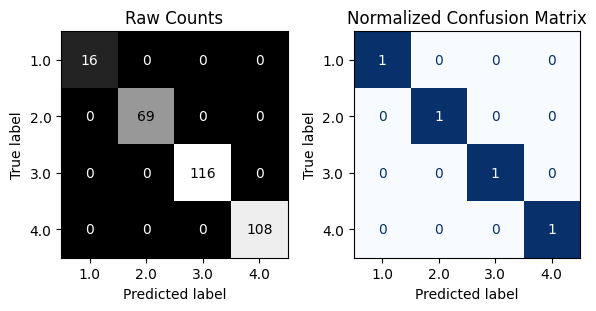


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         5
         2.0       0.30      0.26      0.28        23
         3.0       0.48      0.56      0.52        39
         4.0       0.68      0.69      0.68        36

    accuracy                           0.51       103
   macro avg       0.36      0.38      0.37       103
weighted avg       0.48      0.51      0.50       103



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


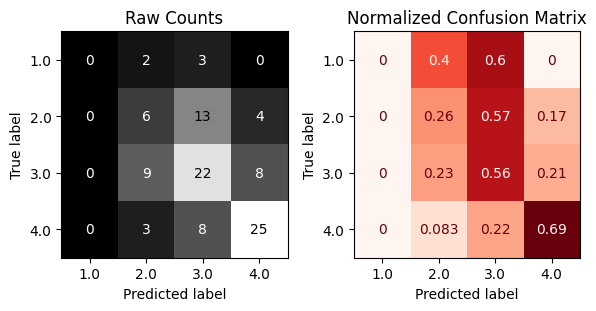

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [62]:
# default model
rf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)

evaluate_classification(rf_pipe,X_train, y_train, X_test, y_test)

> **Default Random Forest Evaluation**
>
> The default Random Forest model achieved **100% training accuracy**, precision, recall, and F1-score, indicating that it perfectly memorized the training data. However, its performance dropped substantially on the test set, achieving an **accuracy of 51%** and a **macro F1-score of 0.37**, which suggests poor generalization and overfitting.
>
> The model performed best on **Stage 4**, with a recall of **0.69**, while it struggled to classify the minority classes. In particular, **Stage 1** was never predicted, resulting in **0% precision, recall, and F1-score** for that class. This is likely due to the severe class imbalance, as Stage 1 contains very few training samples compared to the other stages.
>
> Overall, the default Random Forest overfits the training data and performs poorly on unseen data. Hyperparameter tuning and techniques to address class imbalance, such as using `class_weight='balanced'`, are recommended to improve the model's generalization and minority class performance.
>

### Feature Importance

In [70]:
# Function to create a color dictionary
def get_color_dict(
    importances,
    color_rest='#006ba4',
    color_top='green',
    top_n=5
):
    # Get the names of the top features
    highlight_feats = (
        importances
        .sort_values(ascending=True)
        .tail(top_n)
        .index
    )

    # Assign green to top features and blue to the remaining features
    colors_dict = {
        col: color_top if col in highlight_feats else color_rest
        for col in importances.index
    }

    return colors_dict

# Function to plot feature importance
def plot_importance_color(
    importances,
    top_n=None,
    figsize=(8, 6),
    color_dict=None
):
    # Sort the importance values
    if top_n is None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    # Plot using the provided colors
    if color_dict is not None:
        colors = plot_vals.index.map(color_dict)

        ax = plot_vals.plot(
            kind='barh',
            figsize=figsize,
            color=colors
        )

    else:
        ax = plot_vals.plot(
            kind='barh',
            figsize=figsize
        )

    # Labels and title
    ax.set(
        xlabel='Importance',
        ylabel='Feature Names',
        title=title
    )

    return ax

In [71]:
# Calculate permutation importance using unseen test data
r = permutation_importance(
    rf_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1
)

# Check the returned results
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

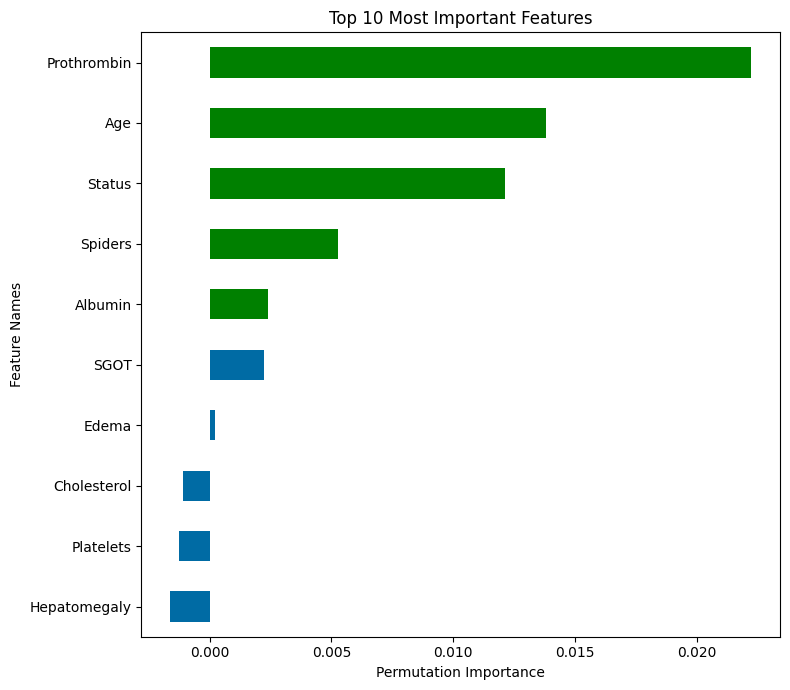

In [74]:
# Convert mean permutation importances into a Series
permutation_importances = pd.Series(
    r['importances_mean'],
    index=X_test.columns,
    name='Permutation Importance'
)

# Sort from highest to lowest
permutation_importances = permutation_importances.sort_values(
    ascending=False
)

colors_top5 = get_color_dict(
    permutation_importances,
    top_n=5
)

ax = plot_importance_color(
    permutation_importances,
    color_dict=colors_top5,
    top_n=10,
    figsize=(8, 7)
)

ax.set_xlabel("Permutation Importance")

plt.tight_layout()

> **Permutation Importance Observations**
>
> Permutation importance identified `Prothrombin` as the most influential feature for predicting the stage of cirrhosis, followed by `Age`, `Status`, `Spiders`, and `Albumin`. These features had the greatest impact on the model's predictive performance, as shuffling them resulted in the largest decrease in the model's macro F1-score.
>
> The remaining features, including **SGOT**, **Edema**, **Cholesterol**, **Platelets**, and **Hepatomegaly**, showed little or negative importance, indicating that they contributed relatively little to the model's predictions compared with the top features.
>
> The identified important features are consistent with the business problem of predicting cirrhosis stage. **Prothrombin** and **Albumin** are widely used clinical measures of liver function, while **Spiders** (spider angiomas) are a common physical sign of advanced liver disease. **Age** is an important risk factor, as disease progression generally increases with age. **Status** reflects the patient's clinical condition and is therefore strongly associated with disease severity.
>
> Overall, the permutation importance results indicate that the model relies primarily on clinically meaningful variables, suggesting that its predictions are based on medically relevant indicators rather than arbitrary patterns in the data.

### Explanatory Data Analysis

In [75]:
def plot_feature_by_stage(
    df,
    feature,
    target='Stage',
    figsize=(8, 5),
    order=None

):
    # Create a temporary copy for visualization
    temp_df = df.copy()

    # Remove rows missing either the feature or target
    temp_df = temp_df.dropna(subset=[feature, target])

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Show individual patient observations
    sns.stripplot(
        data=temp_df,
        x=target,
        y=feature,
        hue=target,
        order=order,
        hue_order=order,
        legend=False,
        edgecolor='white',
        linewidth=0.5,
        size=4,
        alpha=0.7,
        jitter=0.25,
        zorder=0,
        ax=ax
    )

    # Show the average value for each stage
    sns.barplot(
        data=temp_df,
        x=target,
        y=feature,
        order=order,
        alpha=0.6,
        linewidth=1,
        edgecolor='black',
        errorbar=None,
        ax=ax
    )

    # Reporting-quality labels
    ax.set_title(
        f"Average {feature} Across Cirrhosis Stages",
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlabel("Cirrhosis Stage", fontsize=11)
    ax.set_ylabel(feature, fontsize=11)

    fig.tight_layout()

    return fig, ax

#### Prothrombin vs Stage

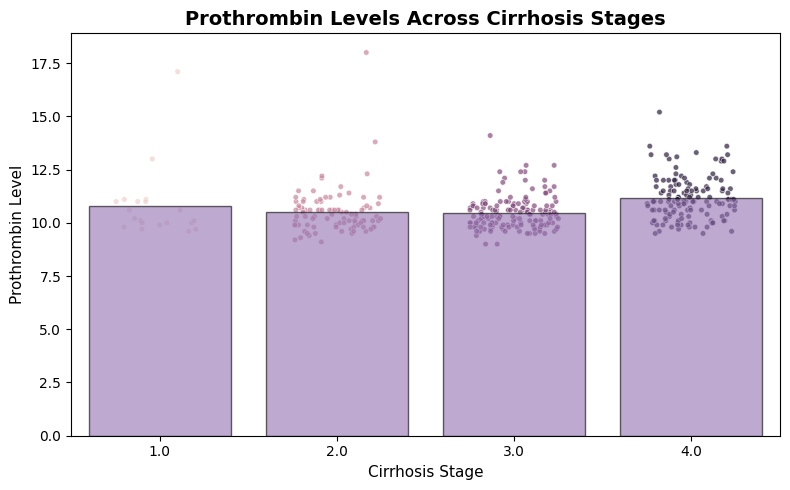

In [76]:
stage_order = [1.0, 2.0, 3.0, 4.0]
fig, ax = plot_feature_by_stage(
    df,
    feature='Prothrombin',
    order=stage_order,
    figsize=(8, 5)
)

ax.set_title(
    "Prothrombin Levels Across Cirrhosis Stages",
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel("Prothrombin Level")
ax.set_xlabel("Cirrhosis Stage")

plt.show()

> **Prothrombin Levels Across Cirrhosis Stages**
>
> The visualization shows that average prothrombin levels remain relatively similar across Stages 1, 2, and 3, while Stage 4 has the highest average level. This suggests that higher prothrombin values may be associated with more advanced cirrhosis.
>
> There is still considerable overlap between the stages, and a few unusually high values appear in the earlier stages. Therefore, prothrombin is useful for identifying general differences in disease severity, but it should not be used alone to determine a patient’s cirrhosis stage.

#### Age vs Stage

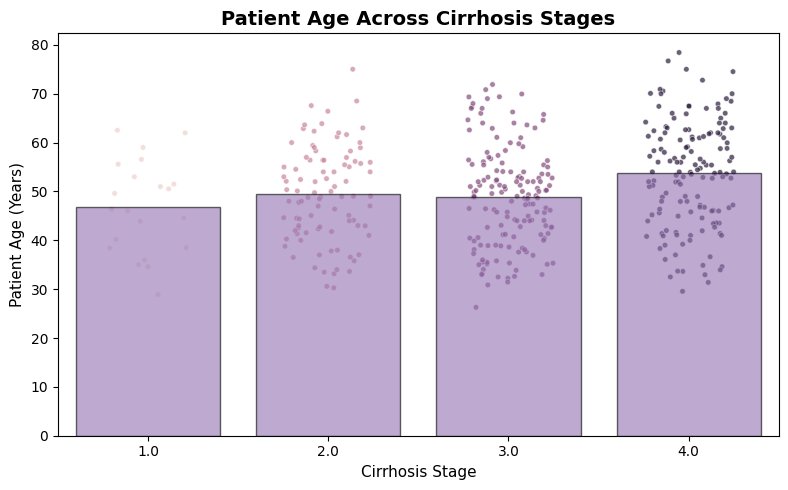

In [77]:
# Temporary copy for visualization
viz_df = df.copy()

# Convert age from days to years
viz_df['Age_Years'] = viz_df['Age'] / 365.25

fig, ax = plot_feature_by_stage(
    viz_df,
    feature='Age_Years',
    order=stage_order,
    figsize=(8, 5)
)

ax.set_title(
    "Patient Age Across Cirrhosis Stages",
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel("Patient Age (Years)")
ax.set_xlabel("Cirrhosis Stage")

plt.show()

> **Patient Age Across Cirrhosis Stages**
>
> Age was identified as an important feature by the Random Forest model because it contributed to distinguishing between cirrhosis stages in this dataset. The average age tends to increase slightly in Stage 4; however, there is substantial overlap in the age distributions across all stages.
>
> This indicates that age alone is not sufficient to determine a patient's cirrhosis stage. Instead, it provides complementary information when combined with other clinical measurements such as Prothrombin, Albumin, and Spiders.

### Tuning with GridCV

In [63]:
params = {
    'randomforestclassifier__max_depth': [None,5, 10, 15, 20],
    'randomforestclassifier__n_estimators': [ 100, 150, 200, 300, 500],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4,6],
    'randomforestclassifier__max_features': ['sqrt', 'log2', None],
    'randomforestclassifier__oob_score': [True, False],
    'randomforestclassifier__min_samples_split': [2, 5, 10]
}

# 5x5x4x3x2x3 = 1800 combinations x 3 folds = 5400 fits

gridsearch = GridSearchCV(rf_pipe, params, n_jobs=-1, cv=3, verbose=1)
gridsearch.fit(X_train, y_train)

print('\n',gridsearch.best_params_,'\n')

# Best model
best_rf = gridsearch.best_estimator_
evaluate_classification(best_rf, X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 1800 candidates, totalling 5400 fits


KeyboardInterrupt: 